<a href="https://colab.research.google.com/github/addycarroll/BGLR/blob/main/A_Carroll_drought_modeling_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### Install and load packages ###

install.packages(c("dplyr", "stringr", "tibble", "purrr", "tidyr", "furrr", "BGLR", "ggplot2", "RColorBrewer"))

library(dplyr)
library(stringr)
library(tibble)
library(purrr)
library(tidyr)
library(furrr)
library(BGLR)
library(ggplot2)
library(RColorBrewer)


### Set up parallel processing ###

plan(multisession,
     workers = parallel::detectCores() - 1L)
options(future.rng.onMisuse = "ignore")

### Define base URL for data files stored in GitHub repository ###
base_url <- "https://raw.githubusercontent.com/addycarroll/BGLR/main/"

### Define generic function to import files from GitHub ###
read_remote <- function(fname, FUN, ...) {
  url <- paste0(base_url, URLencode(fname))
  FUN(url, ...)
}

## Convenience wrapper functions for different file types
# 1) CSV files (BLUEs, kinship)
read_remote_csv <- function(fname, ...) {
  read_remote(fname,
              FUN = read.csv,
              stringsAsFactors = FALSE,
              ...)
}

# 2) Text files (GWAS SNPs)
read_remote_geno <- function(fname, ...) {
  read_remote(fname,
              FUN    = read.delim,
              header = FALSE,
              sep    = "\t",
              ...)
}

# 3) Text files (GWAS BLUPs)
read_remote_pheno <- function(fname, ...) {
  read_remote(fname,
              FUN    = read.delim,
              header = TRUE,
              sep    = "\t",
              ...)
}

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘truncnorm’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: future



In [ ]:

### Read and prepare dataframe with BLUEs, weights, and DSI ###
raw <- read_remote_csv(
  "BLUEs_standardized data_drought covariates.csv",) %>%
  # Make sure Environment and Genotype columns are factors
  mutate(Environment = factor(str_trim(Environment)),
         Genotype   = str_trim(Genotype)) %>%
  # Add a column '.orig' to keep the original row order
  mutate(.orig = row_number())


### Convert BLUEs and weights columns to numeric ###
num_cols <- 4:(ncol(raw) - 1)

raw[num_cols] <- lapply(raw[num_cols], function(x) {
  if (is.factor(x)) {
    as.numeric(as.character(x))
  } else if (is.character(x)) {
    as.numeric(x)
  } else {
    x
  }
})

### Make sure no missing DSI for kernel building ###
raw$Cov_DSI[is.na(raw$Cov_DSI)] <- 0


In [ ]:

### Read and align kinship data ###
rawK <- read_remote_csv(
  "BGLR kinship data.csv",
  row.names   = 1,
  header      = FALSE,
  check.names = FALSE
)

### Convert into a matrix ###
Kzhang <- as.matrix(rawK)

### Clean up the row/column names and ensure matrix symmetry ###
idsK <- str_trim(rownames(Kzhang))
rownames(Kzhang) <- idsK
colnames(Kzhang) <- idsK

### Subset BLUEs and kinship to share the same IDs ###
geno_ids <- intersect(raw$Genotype, idsK)

raw_filt <- raw %>%
  filter(Genotype %in% geno_ids) %>%
  mutate(Genotype = factor(Genotype, levels = geno_ids))

Ksub <- Kzhang[geno_ids, geno_ids]



In [ ]:
### Create design (incidence) matrices and kernels ###

### Environment incidence matrix ###
# One column per Environment
# Each row has a 1 in the column matching its Environment, 0 elsewhere
Ze_full <- model.matrix(~ 0 + Environment, data = raw_filt)

### Genotype incidence matrix ###
# One column per Genotype
# Map each record-level observation to its Genotype identifier
Zg_full <- model.matrix(~ 0 + Genotype, data = raw_filt)

#### Observation-level genomic relationship kernel ###
# Expand the genotype-level kinship out to every record-level observation
# Identifies the expected genetic covariance between two observations based on their kinship
Kobs_g_full <- Zg_full %*% Ksub %*% t(Zg_full)

### Observation-level environmental relationship kernel ###
# Identifies the expected relationship between observations based on if they're in the same Environment (environmental covariance structure)
Kenv_full <- Ze_full %*% t(Ze_full)

In [ ]:
### Define traits and training/testing split by Environment ###

# Environments designated for model training under drought conditions
planned_drought_envs <- c(
  "2021 THD",
  "2022 EL",
  "2022 THD",
  "2023 RL"
)

# The hold-out test Environment
test_env <- "2022 RL"

### Extract the traits as columns that end in '_blue' ###
trait_bases <- raw_filt %>%
  select(ends_with("_blue")) %>%
  names() %>%
  str_remove("_blue$")

In [ ]:
### Parallel loop over traits ###
# -- This takes around 40mins to run -- #
set.seed(1234)
results_and_blups <- future_map(
  trait_bases,
  function(tr) {
    # Define column names for the current trait
    blue_col <- paste0(tr, "_blue")
    wt_col   <- paste0(tr, "_weight")
    adj_col  <- paste0(tr, "_adj")

    # Subset to observations with non‐missing BLUEs and weights
    df0 <- raw_filt %>%
      select(.orig, Environment, Genotype,
             trait_blue   = all_of(blue_col),
             trait_weight = all_of(wt_col),
             Cov_DSI) %>%
      filter(!is.na(trait_blue), !is.na(trait_weight))

    # Identify which of the training Environments are present in df0
    drought_envs_this <- intersect(planned_drought_envs,
                                   unique(df0$Environment))

    # Within‐environment DSI adjustment
    df <- df0 %>%
      group_by(Environment) %>%
      do({
        d <- .
        if (unique(d$Environment) %in% drought_envs_this) {
          fm <- lm(trait_blue ~ Cov_DSI,
                   weights = trait_weight,
                   data    = d)
          d[[adj_col]] <- resid(fm)
        } else {
          d[[adj_col]] <- d$trait_blue
        }
        d
      }) %>%
      ungroup()

    # Subset incidence matrices & kernels to the current data frame
    idx    <- match(df$.orig, raw_filt$.orig)
    Ze_t   <- Ze_full[idx, , drop = FALSE]
    Zg_t   <- Zg_full[idx, , drop = FALSE]
    K_g_t  <- Kobs_g_full[idx, idx]
    # Create G×E kernel: product of genetic & env kernels
    K_ge_t <- K_g_t * Kenv_full[idx, idx]

    # Eigendecomposition
    eig      <- eigen(K_ge_t, symmetric = TRUE)
    eig$values[eig$values < 0] <- 0
    K_ge_t   <- eig$vectors %*% diag(eig$values) %*% t(eig$vectors)

    # Define hold out Environment and number of individuals in training
    hold   <- which(df$Environment == test_env)
    n_eff  <- nrow(df) - length(hold)
    # Weight normalization
    w_norm <- df$trait_weight / mean(df$trait_weight)

    # Function to fit BGLR and compute performance metrics
    fit_and_stats <- function(resp, label, add_slope = FALSE) {
      # Mask test‐env responses to NA for training
      y_all       <- resp
      y_all[hold] <- NA
      varY        <- var(resp, na.rm = TRUE)

      # Build list of random‐effect terms
      ETA <- list(
        # Environment effect (BRR)
        list(X   = Ze_t,    model = "BRR",  df0 = 5, S0 = varY * 0.2),
        # Main genetic effect (RKHS)
        list(K   = K_g_t,   model = "RKHS", df0 = 5, S0 = varY * 0.2),
        # Genotype×Environment interaction (RKHS)
        list(K   = K_ge_t,  model = "RKHS", df0 = 5, S0 = varY * 0.2)
      )
      # DSI slope (reaction‐norm)
      if (add_slope) {
        ETA[[4]] <- list(
          X     = Zg_t * df$Cov_DSI,
          model = "BRR", df0 = 5, S0 = varY * 0.2
        )
      }

      # Fit the BGLR model
      fit <- BGLR(
        y             = y_all,
        ETA           = ETA,
        weights       = w_norm,
        response_type = "gaussian",
        nIter         = 15000,
        burnIn        = 5000,
        thin          = 5,
        verbose       = FALSE
      )

      # Assess performance both in-sample and in hold-out test
      R2_in   <- cor(resp[-hold], fit$yHat[-hold])^2
      RMSE_in <- sqrt(mean((resp[-hold] - fit$yHat[-hold])^2))
      R2_test <- cor(df$trait_blue[hold], fit$yHat[hold])^2
      RMSE_te <- sqrt(mean((df$trait_blue[hold] - fit$yHat[hold])^2))

      # Extract variance components and calculate genetic repeatability
      v_env  <- fit$ETA[[1]]$varB
      v_g    <- fit$ETA[[2]]$varU
      v_ge   <- fit$ETA[[3]]$varU
      v_eps  <- fit$varE
      repeatability <- v_g / (v_env + v_g + v_ge + v_eps)

      # Calculate AIC & BIC from posterior mean log‑lik and effective number of parameters
      loglik <- fit$fit$postMeanLogLik
      pD     <- fit$fit$pD
      AIC    <- -2 * loglik + 2 * pD
      BIC    <- -2 * loglik + log(n_eff) * pD

      # Return summary statistics
      tibble(
        trait         = tr,
        model         = label,
        R2_in         = R2_in,
        RMSE_in       = RMSE_in,
        R2_test       = R2_test,
        RMSE_test     = RMSE_te,
        repeatability = repeatability,
        AIC           = AIC,
        BIC           = BIC,
        var_Env       = v_env,
        var_G         = v_g,
        var_GxE       = v_ge,
        var_Residual  = v_eps
      )
    }

    # Fit model and extract metrics for each modeling scenario
    stats_u  <- fit_and_stats(df$trait_blue,   "unadj",               FALSE)
    stats_a  <- fit_and_stats(df[[adj_col]],   "adjusted",            FALSE)
    stats_rn <- fit_and_stats(df$trait_blue,   "reaction_norm_unadj", TRUE)
    stats    <- bind_rows(stats_u, stats_a, stats_rn)

    # Fit BGLR on full dataset to extract BLUPs
    fit_full <- function(y_resp, add_slope = FALSE) {
      varY <- var(y_resp, na.rm = TRUE)
      ETA  <- list(
        list(X   = Ze_t,   model = "BRR",  df0 = 5, S0 = varY * 0.2),
        list(K   = K_g_t,  model = "RKHS", df0 = 5, S0 = varY * 0.2),
        list(K   = K_ge_t, model = "RKHS", df0 = 5, S0 = varY * 0.2)
      )
      if (add_slope) {
        ETA[[4]] <- list(
          X     = Zg_t * df$Cov_DSI,
          model = "BRR", df0 = 5, S0 = varY * 0.2
        )
      }
      BGLR(
        y             = y_resp,
        ETA           = ETA,
        weights       = w_norm,
        response_type = "gaussian",
        nIter         = 15000,
        burnIn        = 5000,
        thin          = 5,
        verbose       = FALSE
      )
    }

    fu  <- fit_full(df$trait_blue, FALSE)
    fa  <- fit_full(df[[adj_col]], FALSE)
    frn <- fit_full(df$trait_blue, TRUE)

    # Collapse BLUPs to across-environment average
    collapse_u <- function(u_vec) {
      tibble(Genotype = df$Genotype,
             BLUP_obs = u_vec) %>%
        filter(!is.na(BLUP_obs)) %>%
        group_by(Genotype) %>%
        summarise(BLUP = mean(BLUP_obs), .groups = "drop")
    }

    bu  <- collapse_u(fu$ETA[[2]]$u)  %>% rename(BLUP_unadj = BLUP)
    ba  <- collapse_u(fa$ETA[[2]]$u)  %>% rename(BLUP_adj   = BLUP)
    brn <- collapse_u(frn$ETA[[2]]$u) %>% rename(BLUP_rn    = BLUP)

    # Merge the BLUPs and add trait identifiers
    blup_df <- reduce(list(bu, ba, brn), left_join, by = "Genotype") %>%
      mutate(trait = tr)

    # Return a list with the performance metrics and BLUPs dataframe
    list(stats = stats,
         blups = blup_df)
  },
  .options = furrr_options(seed = TRUE)
)


In [ ]:

### Combine results across traits and models ###
results_df <- map_dfr(results_and_blups, "stats")

blups_df <- map_dfr(results_and_blups, "blups")

### Print the full summary of model performance metrics ###
print(results_df)

### Print the first few rows of the combined BLUP table ###
print(head(blups_df))

# A tibble: 21 × 13
   trait model R2_in RMSE_in R2_test RMSE_test repeatability   AIC   BIC var_Env
   <chr> <chr> <dbl>   <dbl>   <dbl>     <dbl>         <dbl> <dbl> <dbl>   <dbl>
 1 SD    unadj 0.446   0.637  0.305      0.861         0.602 2846. 4078.  0.0445
 2 SD    adju… 0.416   0.623  0.322      0.781         0.616 2838. 4041.  0.0286
 3 SD    reac… 0.510   0.603  0.320      0.833         0.583 2754. 4549.  0.0411
 4 PH    unadj 0.491   0.666  0.321      0.687         0.736 2728. 4130.  0.0318
 5 PH    adju… 0.494   0.660  0.320      0.696         0.728 2741. 4149.  0.0344
 6 PH    reac… 0.534   0.643  0.313      0.691         0.752 2627. 4468.  0.0321
 7 NDVI  unadj 0.553   0.445  0.0667     0.652         0.517  753. 1303.  0.0574
 8 NDVI  adju… 0.370   0.386  0.0574     0.625         0.654  743. 1265.  0.0126
 9 NDVI  reac… 0.617   0.416  0.0489     0.840         0.453  658. 1545.  0.0362
10 GR    unadj 0.360   0.504  0.255      0.430         0.763  806. 1422.  0.0251
# ℹ 11 m

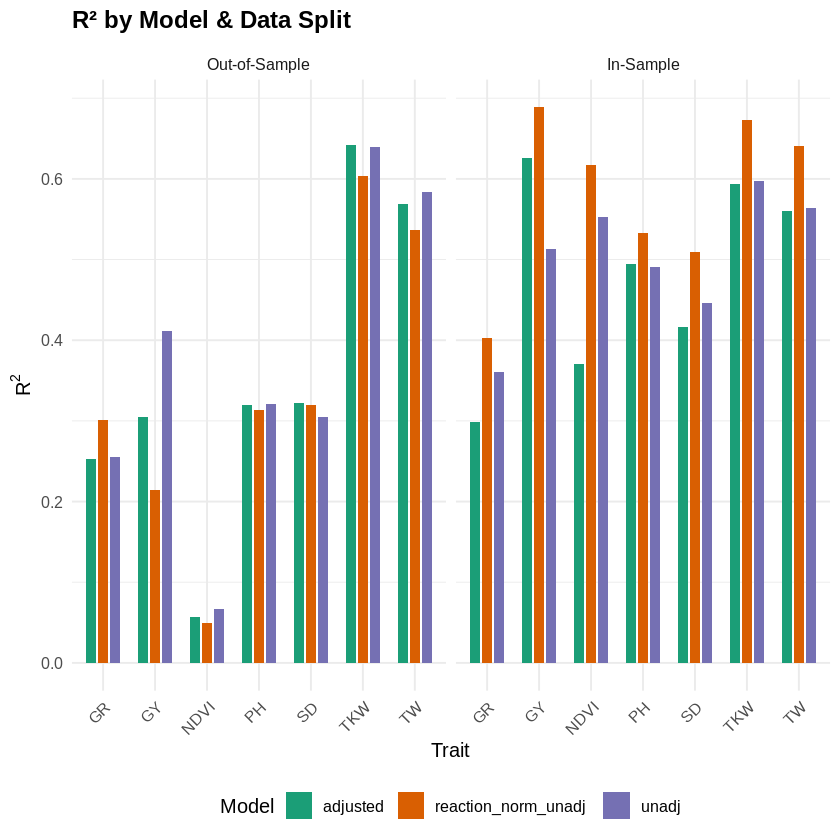

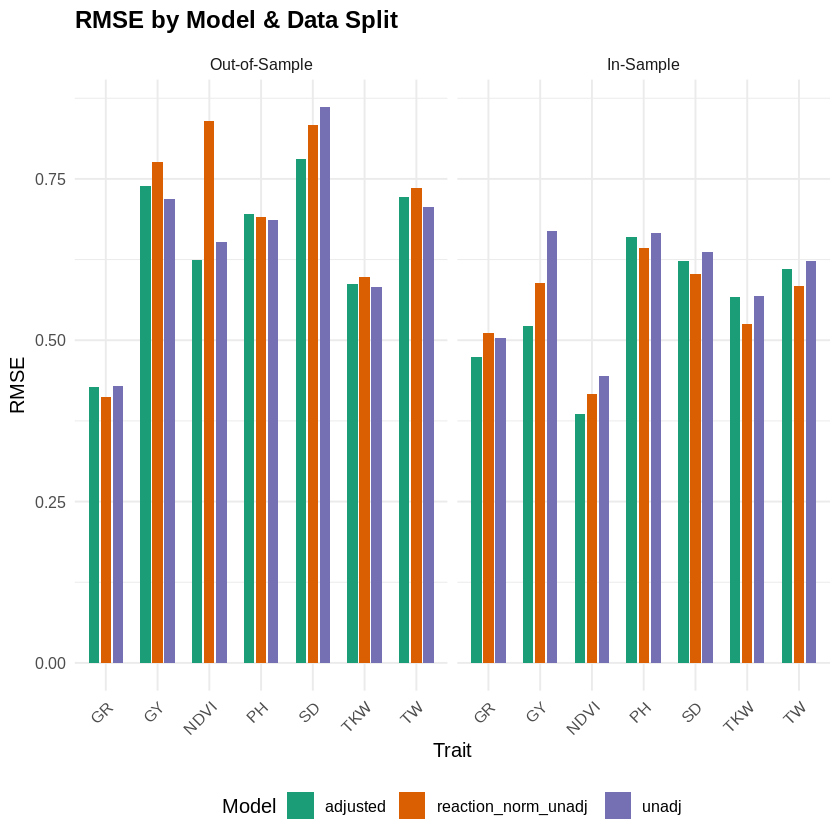

In [ ]:

### Reshape and visualize performance metrics ###
perf_both <- results_df %>%
  select(trait, model, R2_in, RMSE_in, R2_test, RMSE_test) %>%
  pivot_longer(
    cols      = c(R2_in, RMSE_in, R2_test, RMSE_test),
    names_to  = c("metric", "sample"),
    names_sep = "_",
    values_to = "value"
  ) %>%
  mutate(
    metric = recode(metric,
                    R2   = "R²",
                    RMSE = "RMSE"),
    sample = recode(sample,
                    "in"   = "Training",
                    "test" = "Hold‑out")
  )

### Prepare R2 data and plot ###
r2_df <- perf_both %>%
  filter(metric == "R²")

ggplot(r2_df, aes(x = trait, y = value, fill = model)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ sample, nrow = 1,
             labeller = as_labeller(c(
               "Training" = "In-Sample",
               "Hold‑out" = "Out-of-Sample"
             ))) +
  scale_fill_brewer(palette = "Dark2", name = "Model") +
  labs(
    title = expression(bold("R² by Model & Data Split")),
    x     = "Trait",
    y     = expression(R^2)
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x     = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

### Prepare RMSE data and plot ###
rmse_df <- perf_both %>%
  filter(metric == "RMSE")

ggplot(rmse_df, aes(x = trait, y = value, fill = model)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ sample, nrow = 1,
             labeller = as_labeller(c(
               "Training" = "In-Sample",
               "Hold‑out" ="Out-of-Sample"
             ))) +
  scale_fill_brewer(palette = "Dark2", name = "Model") +
  labs(
    title = expression(bold("RMSE by Model & Data Split")),
    x     = "Trait",
    y     = "RMSE"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x     = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )


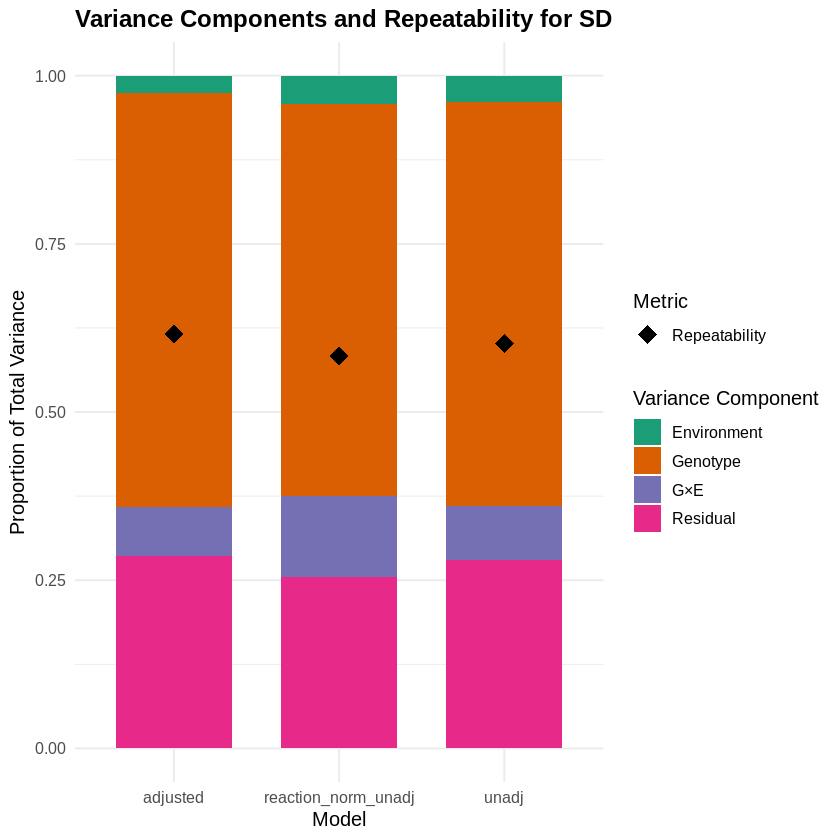

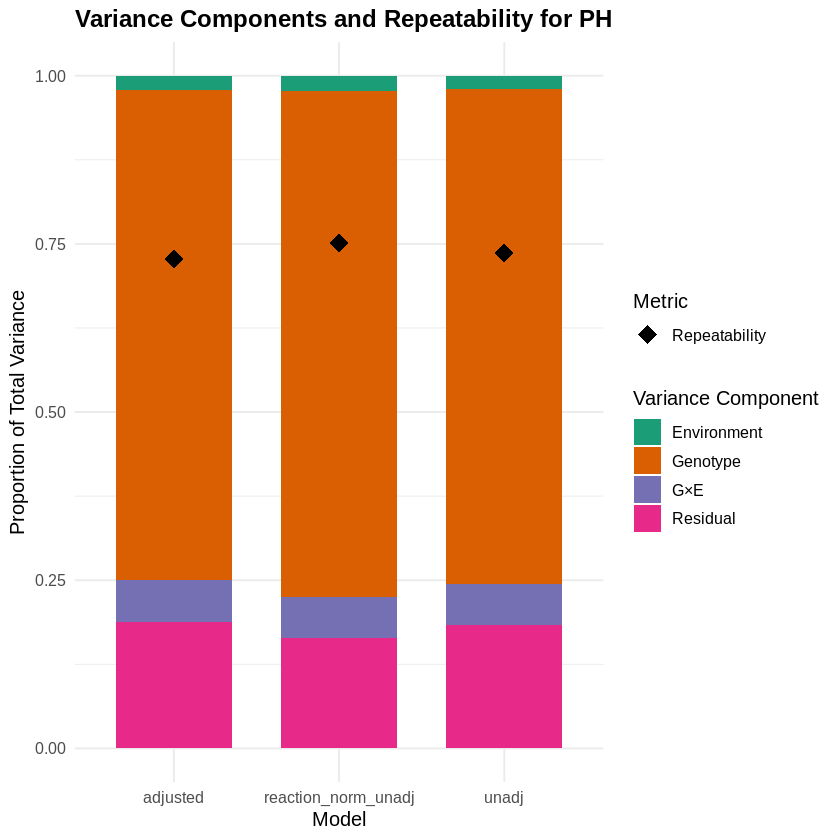

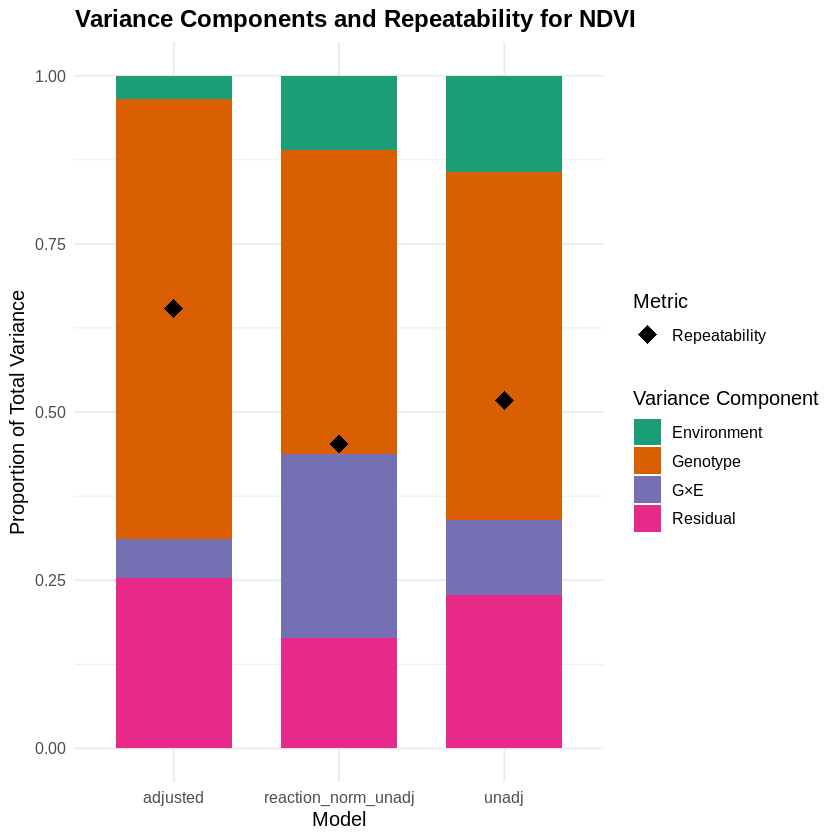

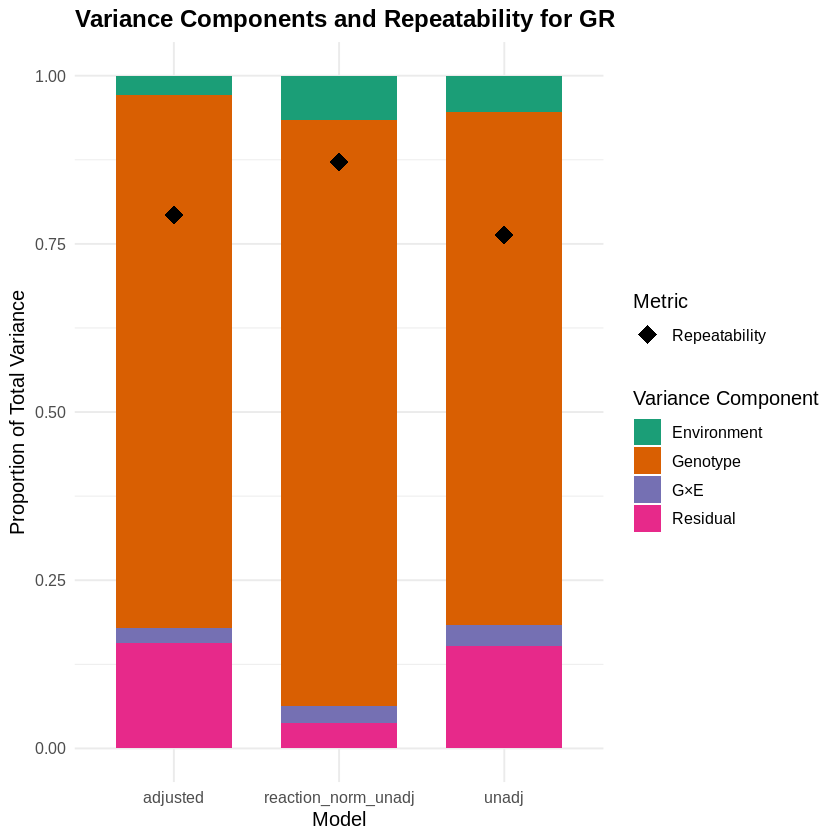

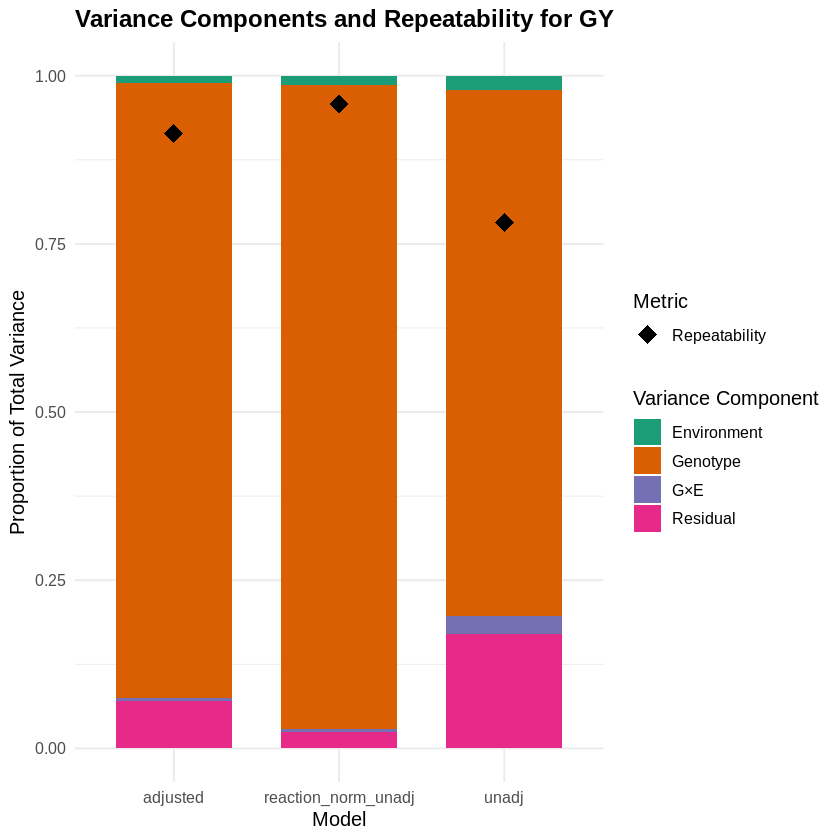

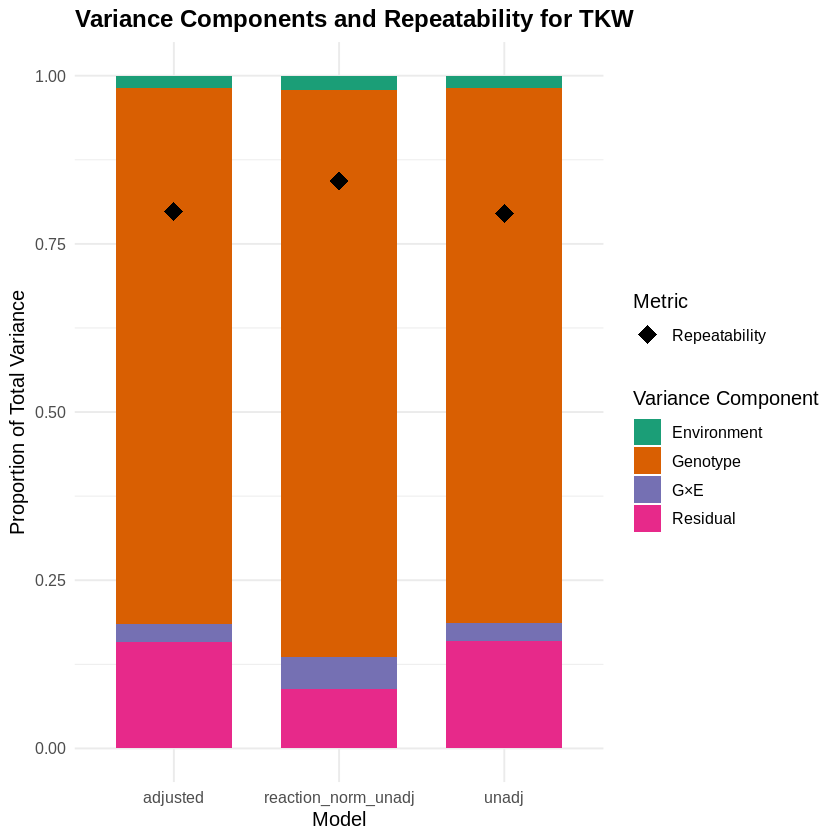

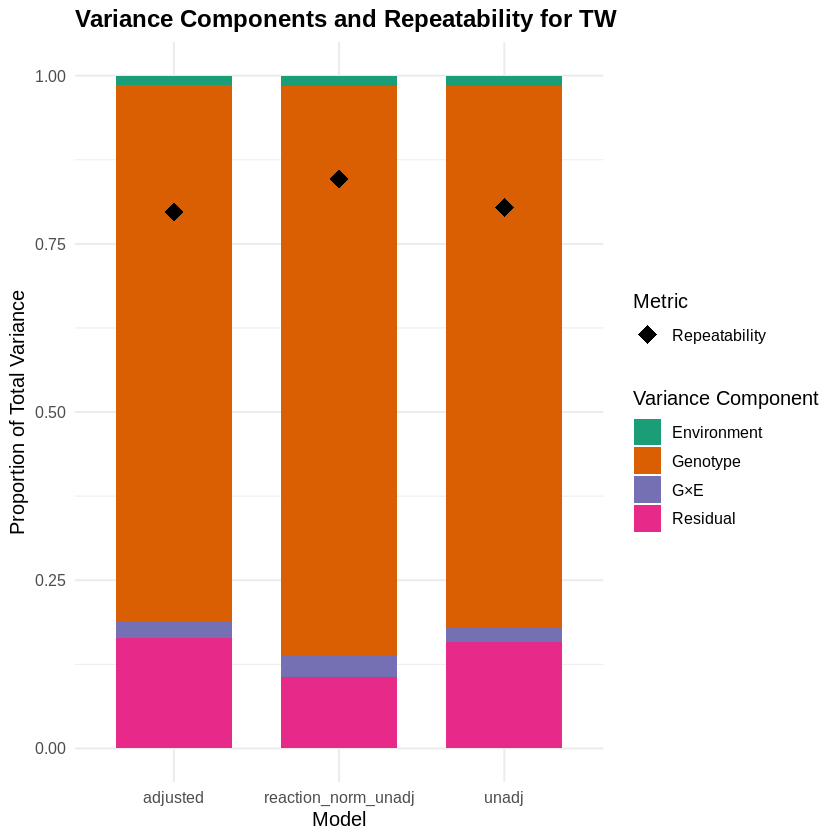

In [ ]:

### Reshape variance components and repeatability and plot by trait ###
vc_df <- results_df %>%
  select(trait, model,
         var_Env, var_G, var_GxE, var_Residual,
         repeatability) %>%
  pivot_longer(
    cols      = c(var_Env, var_G, var_GxE, var_Residual),
    names_to  = "component",
    values_to = "variance"
  ) %>%
  group_by(trait, model) %>%
  mutate(prop = variance / sum(variance)) %>%
  ungroup()

### Extract repeatability into its own table for easy plotting ###
rep_df <- results_df %>%
  select(trait, model, repeatability)

### Loop over each trait to create a combined breakdown of variance components and repeatability ###
unique(vc_df$trait) %>% walk(function(tr) {
  df_vc  <- vc_df  %>% filter(trait == tr)
  df_rep <- rep_df %>% filter(trait == tr)

  # Build the plot
  p <- ggplot(df_vc, aes(x = model, y = prop, fill = component)) +
    geom_col(position = "stack", width = 0.7) +

    # Overlay repeatability as a diamond shape at its value position
    geom_point(
      data        = df_rep,
      aes(x = model, y = repeatability, shape = "Repeatability"),
      color       = "black",
      size        = 5,
      inherit.aes = FALSE,
      position    = position_dodge(width = 0.7)
    ) +

    scale_fill_brewer(
      palette = "Dark2",
      name    = "Variance Component",
      labels  = c(
        var_Env      = "Environment",
        var_G        = "Genotype",
        var_GxE      = "G×E",
        var_Residual = "Residual"
      )
    ) +

    scale_shape_manual(
      name   = "Metric",
      values = c("Repeatability" = 18)
    ) +

    # Titles and axis labels
    labs(
      title = paste("Variance Components and Repeatability for", tr),
      x     = "Model",
      y     = "Proportion of Total Variance"
    ) +

    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold"),
      axis.text.x     = element_text(angle = 0, hjust = 0.5),
      legend.position = "right",
      legend.box      = "vertical"
    )

  # Print the plot for this trait
  print(p)
})


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


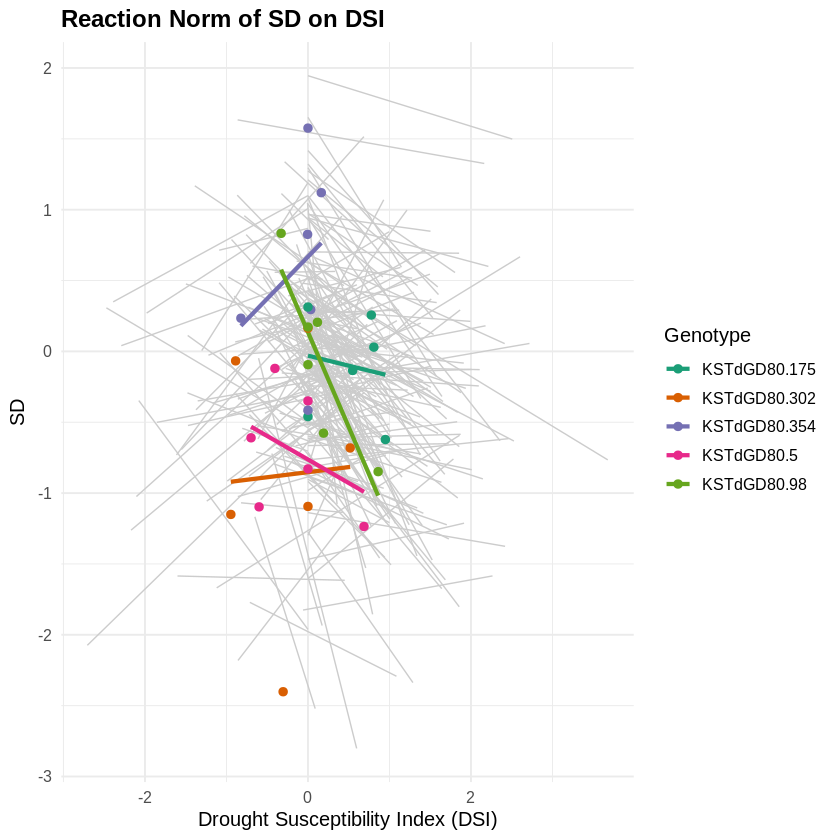

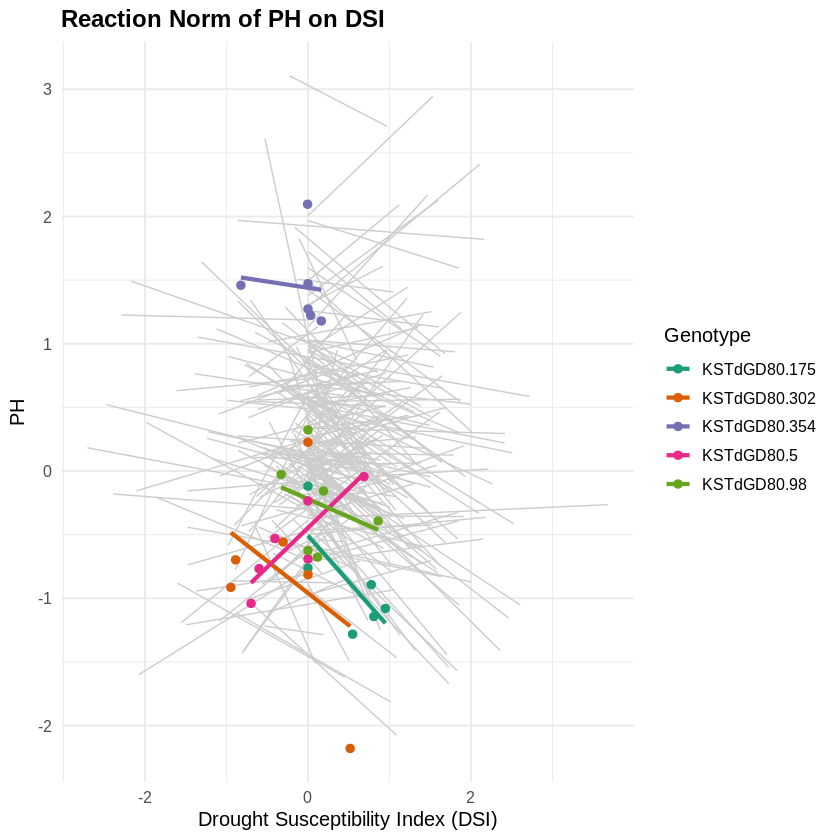

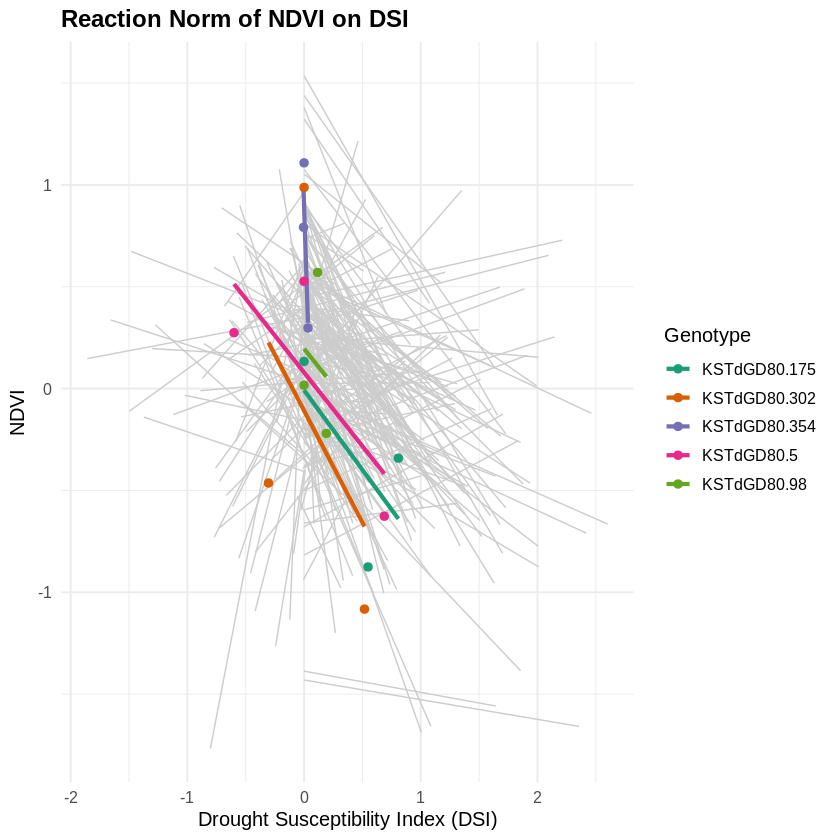

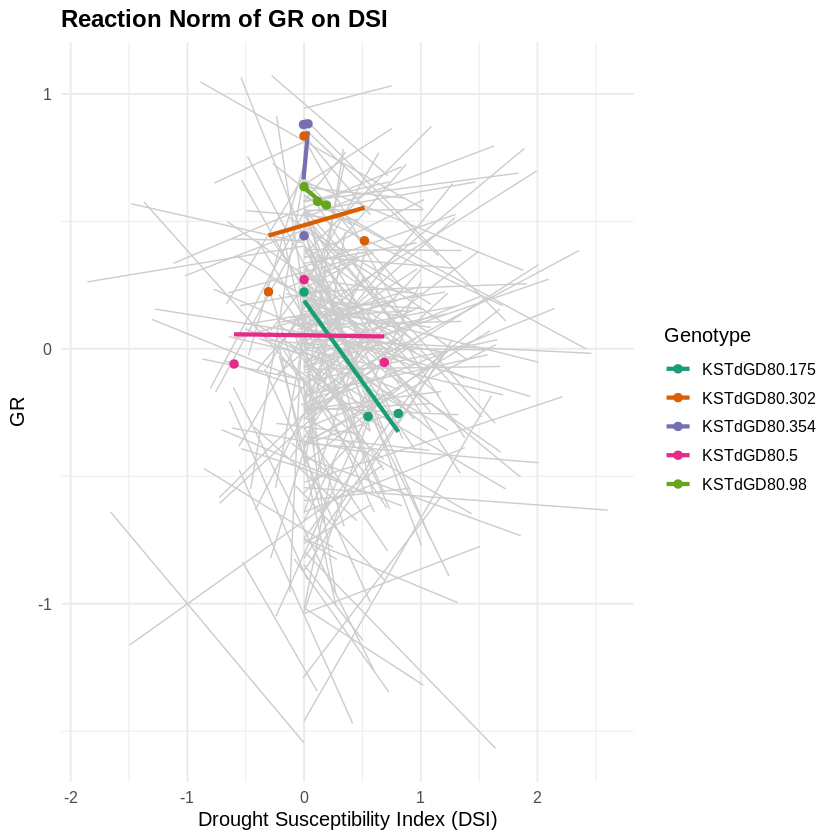

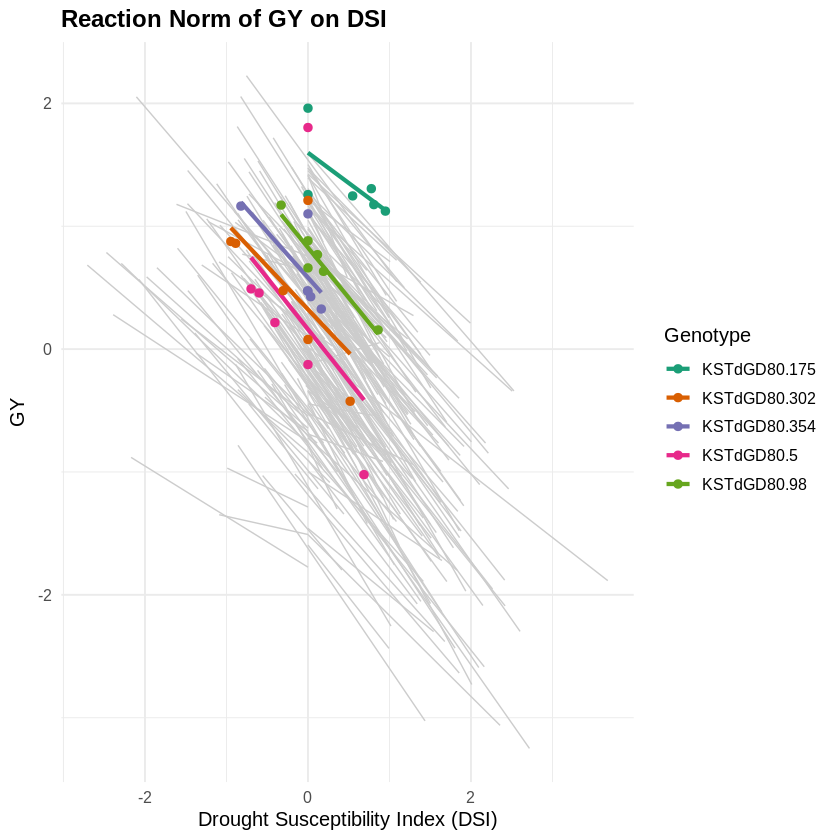

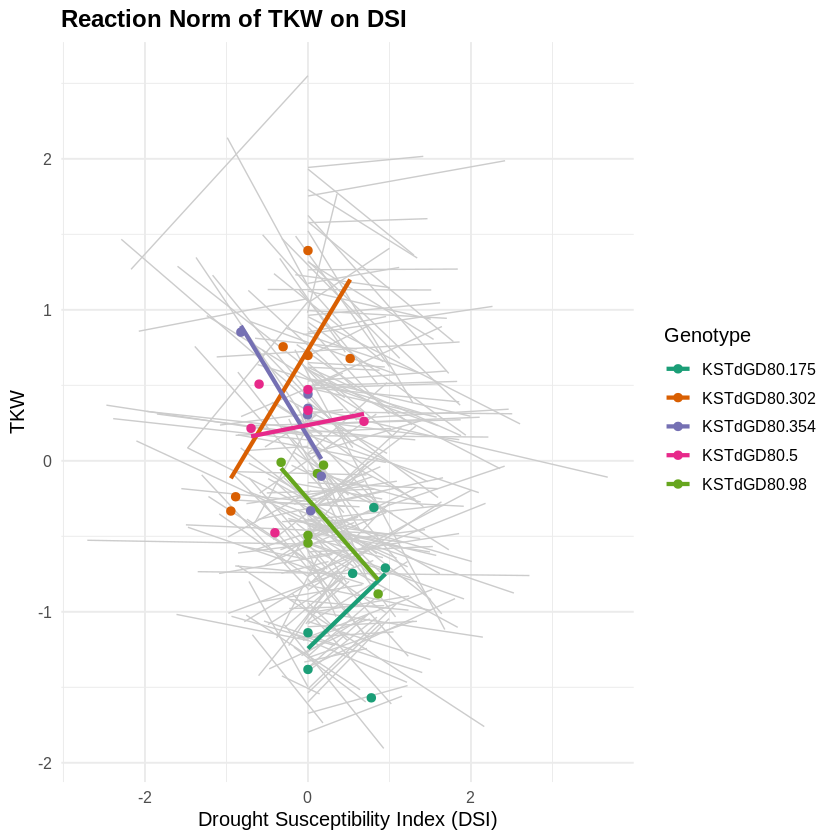

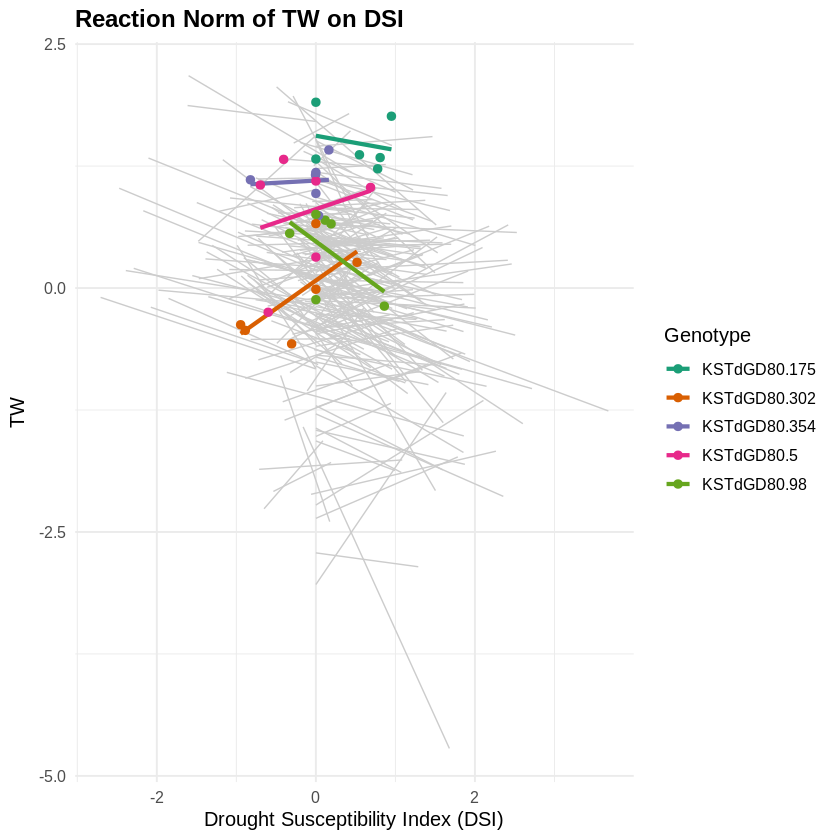

In [ ]:

### Reaction norm plotting ###

### Specify genotypes to highlight in plots ###
highlight_genos <- c(
  "KSTdGD80.175",
  "KSTdGD80.5",
  "KSTdGD80.98",
  "KSTdGD80.354",
  "KSTdGD80.302"
)

### Loop through each trait and create reaction norm plot ###
suppressMessages({
  walk(trait_bases, function(trait_sel) {
    blue_col <- paste0(trait_sel, "_blue")

    df_plot <- raw_filt %>%
      filter(!is.na(.data[[blue_col]])) %>%
      transmute(
        Genotype,
        Cov_DSI,
        trait = .data[[blue_col]]
      )

    p <- ggplot() +

      geom_smooth(
        data    = df_plot,
        aes(x = Cov_DSI, y = trait, group = Genotype),
        method  = "lm",
        se      = FALSE,
        color   = "grey80",
        size    = 0.4
      ) +

      geom_smooth(
        data    = df_plot %>% filter(Genotype %in% highlight_genos),
        aes(x = Cov_DSI, y = trait, color = Genotype),
        method  = "lm",
        se      = FALSE,
        size    = 1.2
      ) +

      geom_point(
        data    = df_plot %>% filter(Genotype %in% highlight_genos),
        aes(x = Cov_DSI, y = trait, color = Genotype),
        size    = 2
      ) +

      scale_color_brewer(
        palette = "Dark2",
        name    = "Genotype"
      ) +

      labs(
        title = paste("Reaction Norm of", trait_sel, "on DSI"),
        x     = "Drought Susceptibility Index (DSI)",
        y     = trait_sel
      ) +
      theme_minimal(base_size = 12) +
      theme(
        plot.title = element_text(face = "bold"),
        legend.position = "right",
        axis.text.x     = element_text(angle = 0, hjust = 0.5)
      )

    print(p)
  })
})


In [ ]:
### Reshape BLUPs for GWAS in GAPIT ###

phenotypes <- blups_df %>%
  pivot_longer(
    cols         = starts_with("BLUP_"),
    names_to     = "model",
    names_prefix = "BLUP_",
    values_to    = "value"
  ) %>%

  unite(
    col    = "trait_model",
    trait,
    model,
    sep    = "_"
  ) %>%

  pivot_wider(
    id_cols     = Genotype,
    names_from  = trait_model,
    values_from = value
  ) %>%

  rename(Taxa = Genotype)

head(phenotypes)

Taxa,SD_unadj,SD_adj,SD_rn,PH_unadj,PH_adj,PH_rn,NDVI_unadj,NDVI_adj,NDVI_rn,⋯,GR_rn,GY_unadj,GY_adj,GY_rn,TKW_unadj,TKW_adj,TKW_rn,TW_unadj,TW_adj,TW_rn
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KSTdGD80.1,-0.691642133,-0.9668996506,-0.79753107,-0.71678588,-1.0003614,-0.808521770,-0.33983639,-0.36880933,-0.20809826,⋯,-0.38470538,-1.75193387,-2.10696458,-2.0911723,1.4773132,0.95464795,0.5743132,-0.5979063,-1.70454940,-0.79499055
KSTdGD80.101,-0.500181969,-0.7758552685,-0.57430823,-0.06524282,-0.3430107,-0.197692225,0.16959712,0.15828972,0.27206281,⋯,-0.23828667,-0.24183213,-0.54269198,-0.8949818,1.4046529,0.88105274,0.5998685,-0.2098705,-1.28752096,-0.69641130
KSTdGD80.102,-0.001149742,-0.2964464933,-0.05343341,-0.19125926,-0.4605715,-0.197210356,-0.03429812,-0.04383153,0.08969714,⋯,-0.71504014,-0.03238352,-0.20448007,-0.2536869,0.4484543,-0.06618281,0.1443249,0.2607918,-0.76145980,-0.02499284
KSTdGD80.103,0.513450128,0.2243767451,0.27456637,0.16677928,-0.1142096,-0.001676372,0.26151686,0.24103933,0.35793406,⋯,0.17620738,0.15699637,-0.21880853,-0.4337725,1.4230233,0.89496671,0.4807344,1.1469349,-0.01296756,0.87281679
KSTdGD80.104,0.635820329,0.3775639222,0.50387541,-1.13571067,-1.4034205,-1.202509438,-0.03543291,-0.06054030,0.05039894,⋯,-0.08711266,-0.32174161,-0.84682263,-1.0281052,-0.2451985,-0.78983997,-1.1904660,0.5665064,-0.73157996,0.14538269
KSTdGD80.106,0.276010660,0.0009266869,0.23632891,-0.02743134,-0.3234403,-0.184205393,0.14175490,0.13000243,0.22069950,⋯,-0.14562375,0.21988610,-0.05317819,-0.1908396,0.2718043,-0.24894547,-0.5280408,1.0949780,-0.05409369,0.75521967


In [ ]:
### Install GAPIT ###
if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")
BiocManager::install()
BiocManager::install(c("multtest", "chopsticks", "snpStats"))
install.packages("gplots")
install.packages("scatterplot3d")
install.packages("genetics")
install.packages("EMMREML")

library('MASS')
library("multtest")
library(gplots)
library("scatterplot3d")
library(genetics)
library(EMMREML)
library(compiler)

### Load GAPIT functions ###
source("http://zzlab.net/GAPIT/gapit_functions.txt")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'BiocVersion'

Old packages: 'base64enc', 'broom', 'bslib', 'cluster', 'cpp11', 'data.table',
  'dbplyr', 'dplyr', 'dtplyr', 'foreign', 'gargle', 'ggplot2', 'httr', 'later',
  'lattice', 'lubridate', 'pkgload', 'rappdirs', 'timechange', 'uuid', 'vctrs',
  'viridisLite', 'vroom', 'xfun', 'xml2'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'multtest', 'chopsticks', 'snpStats'

also instal

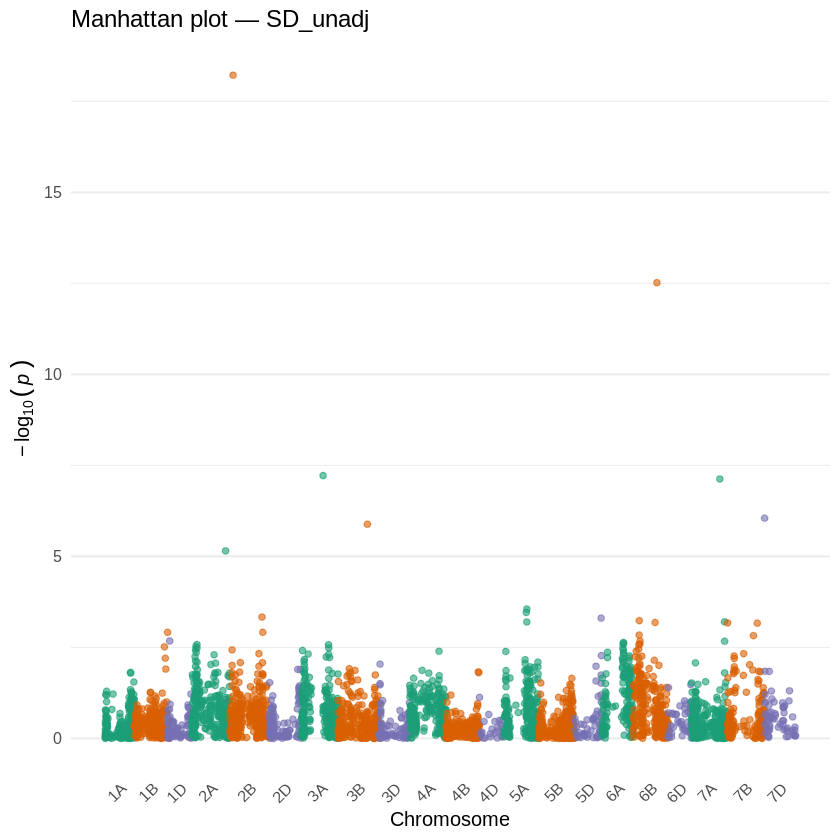

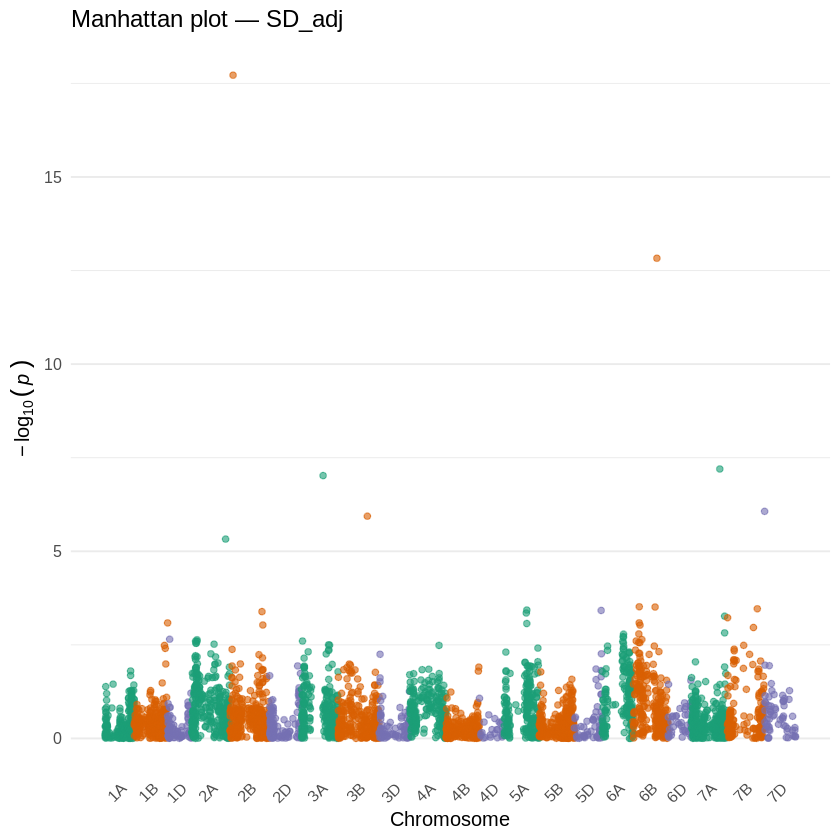

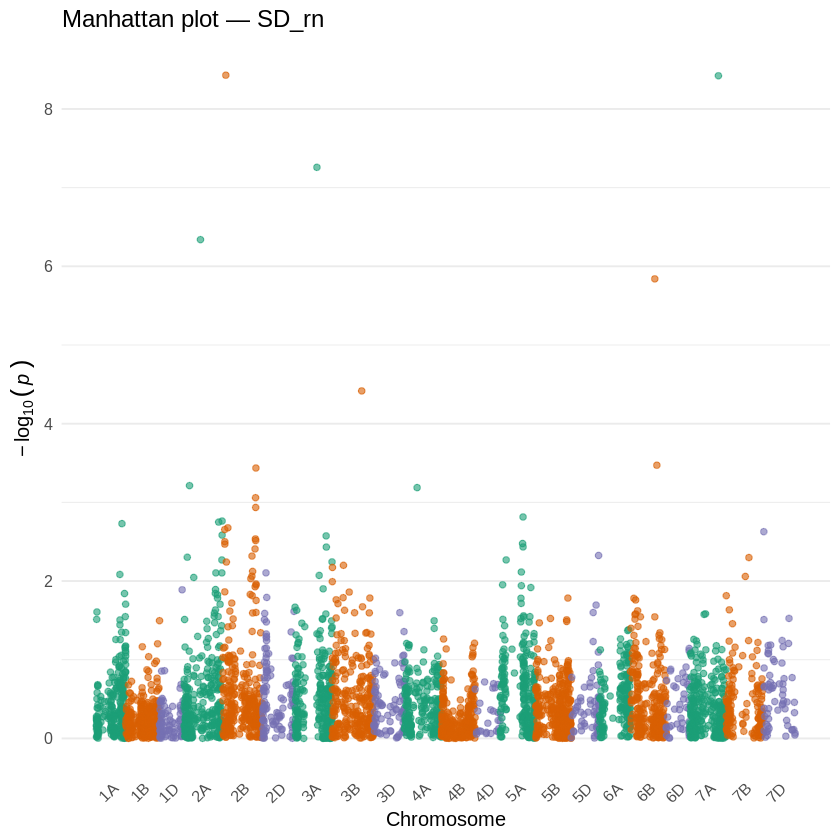

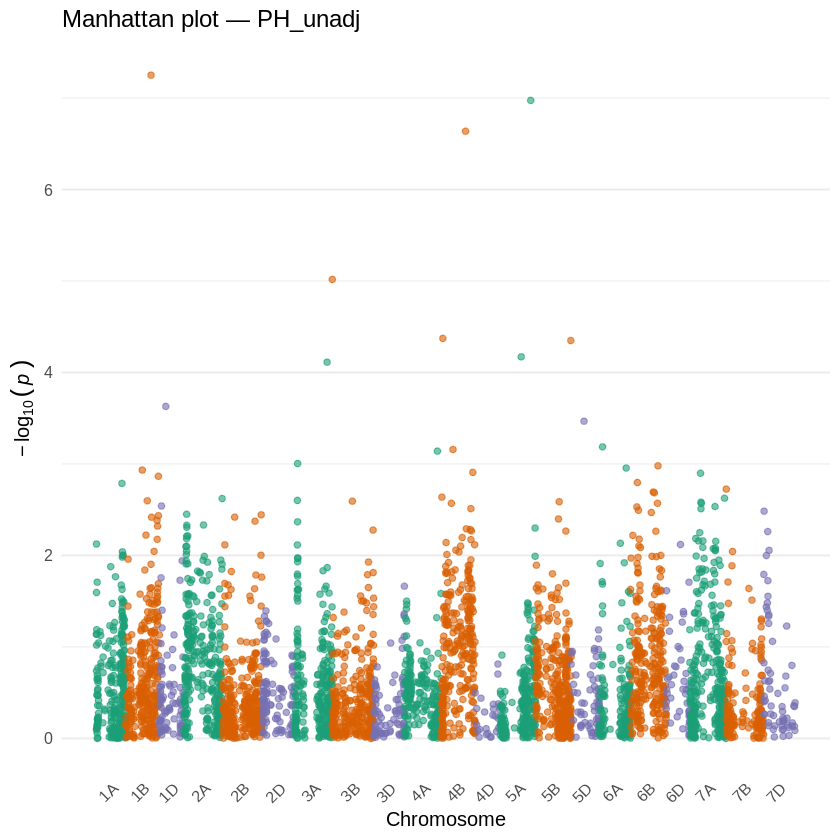

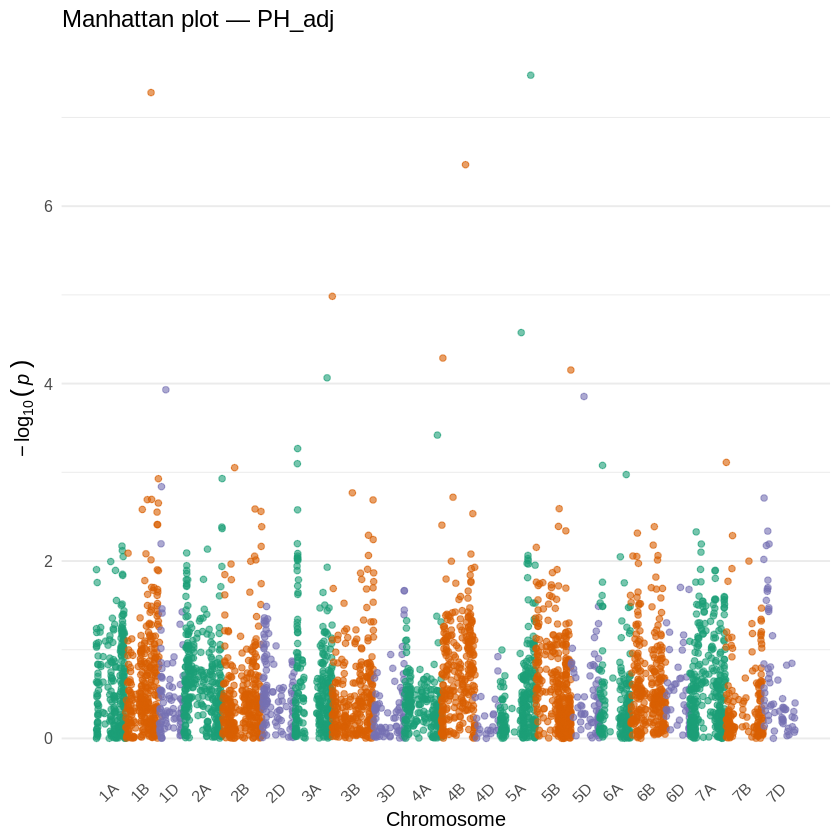

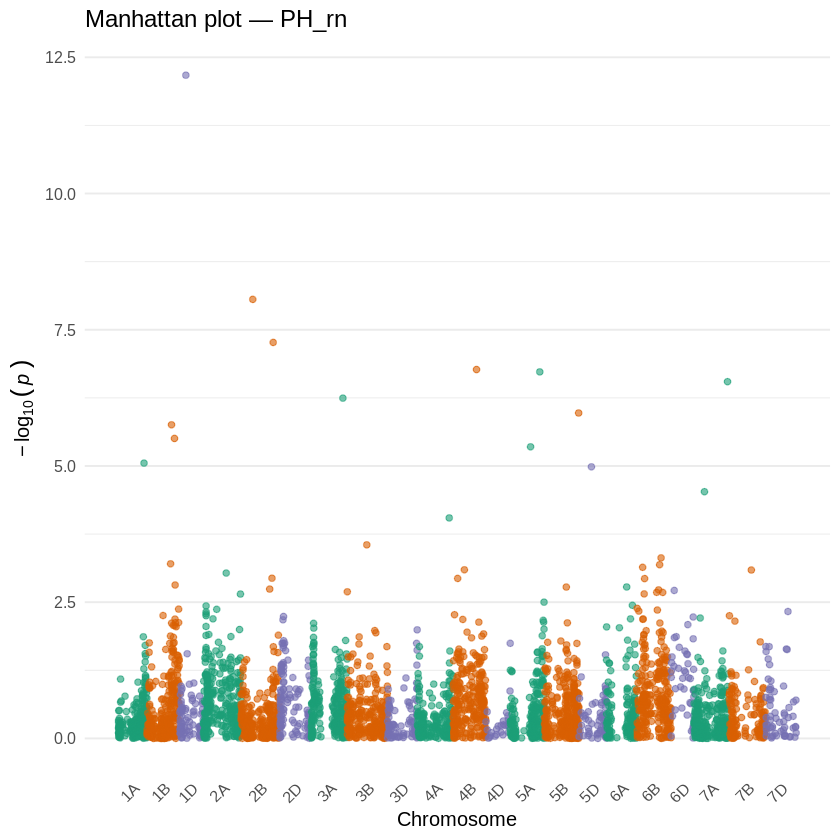

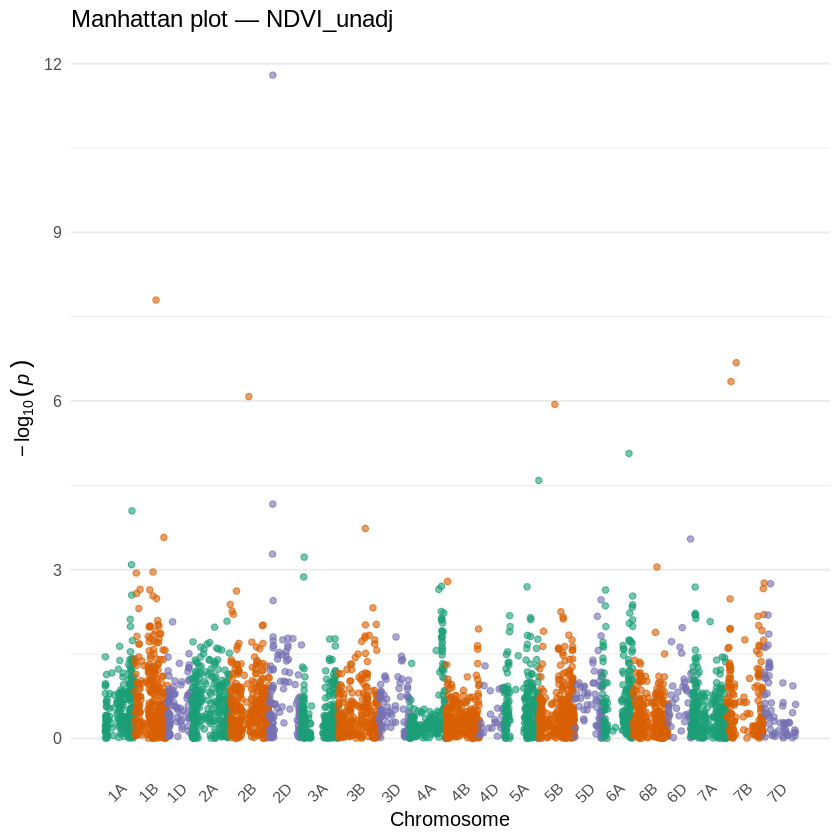

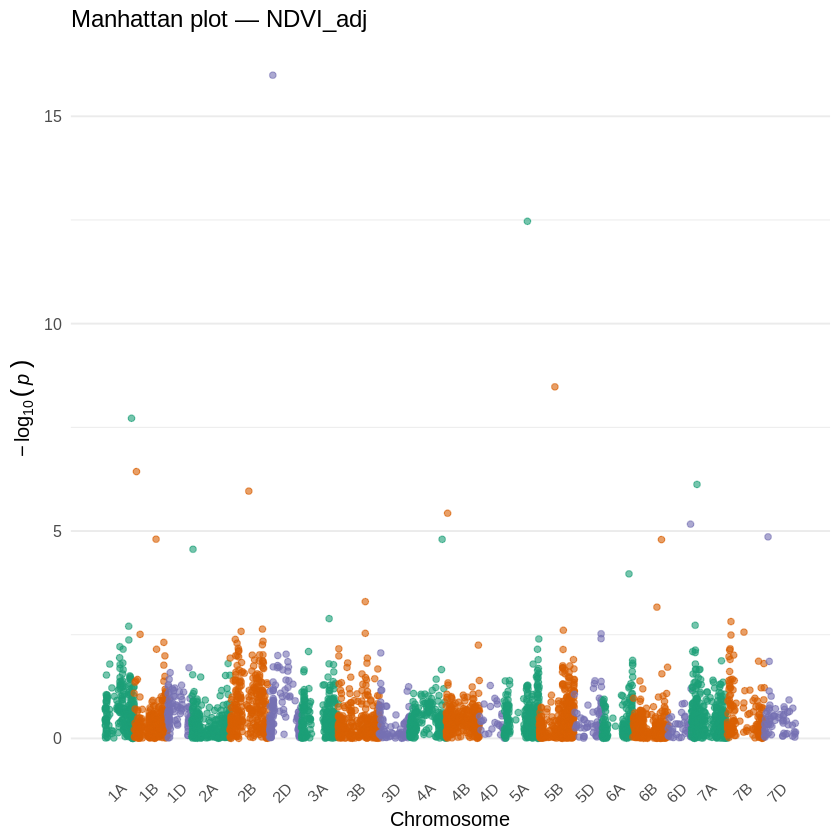

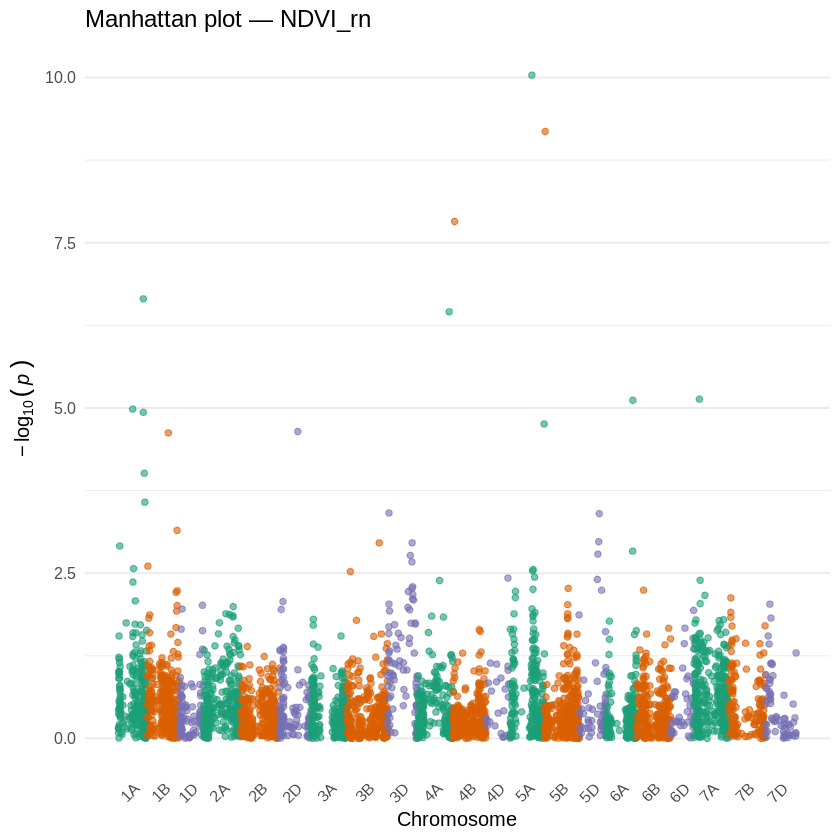

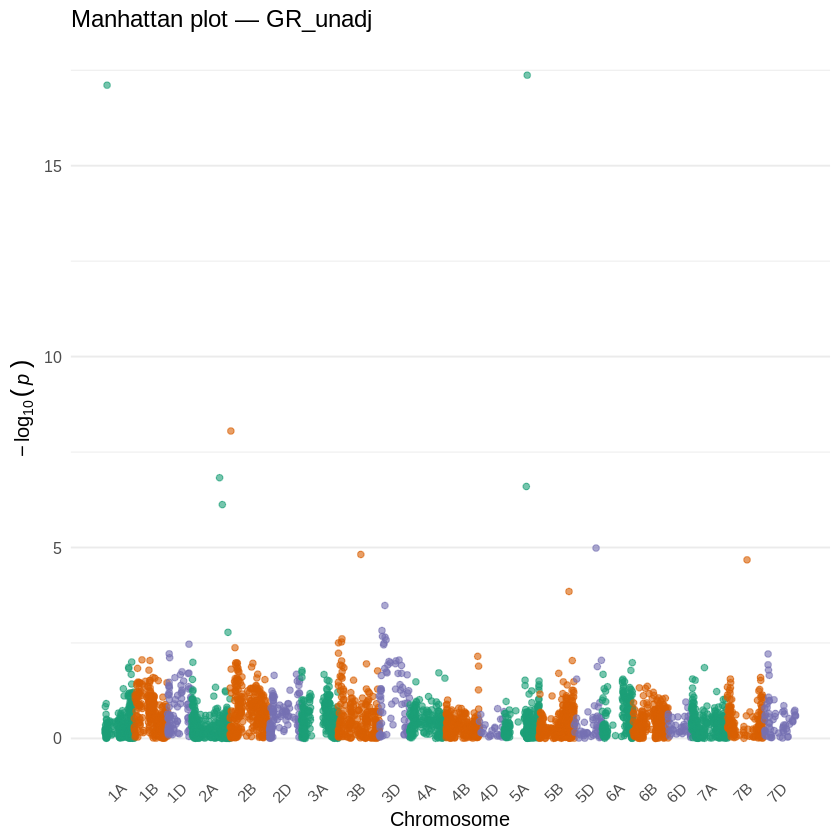

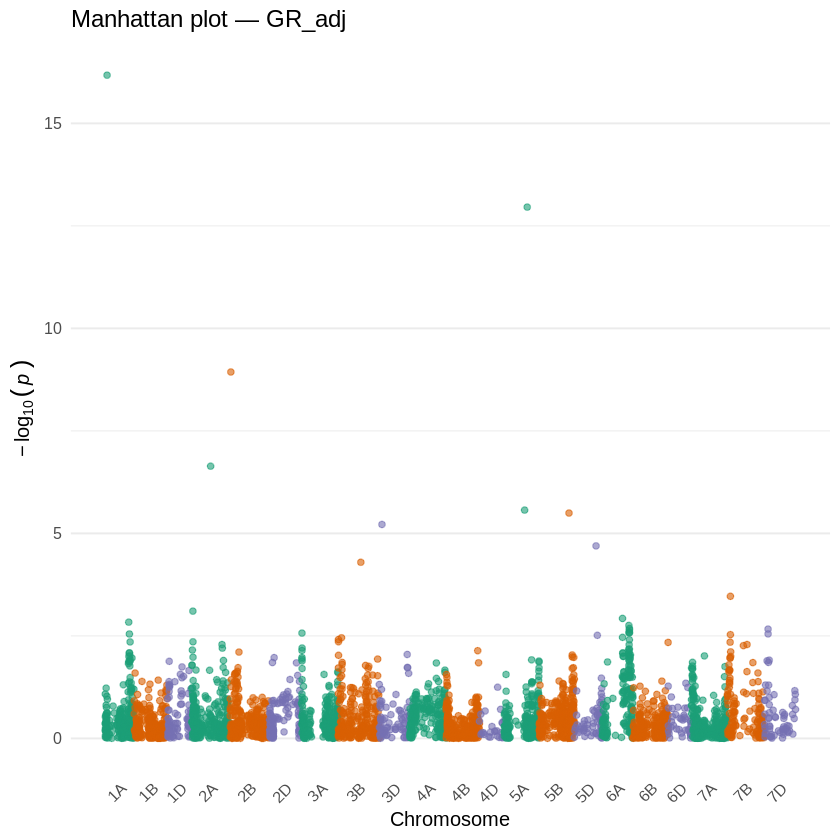

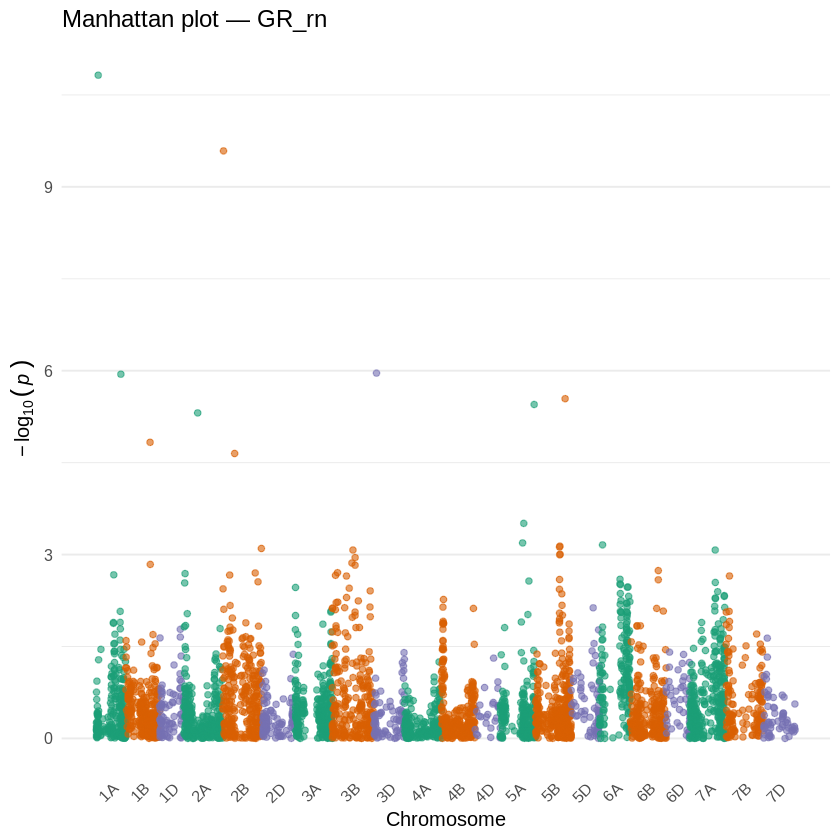

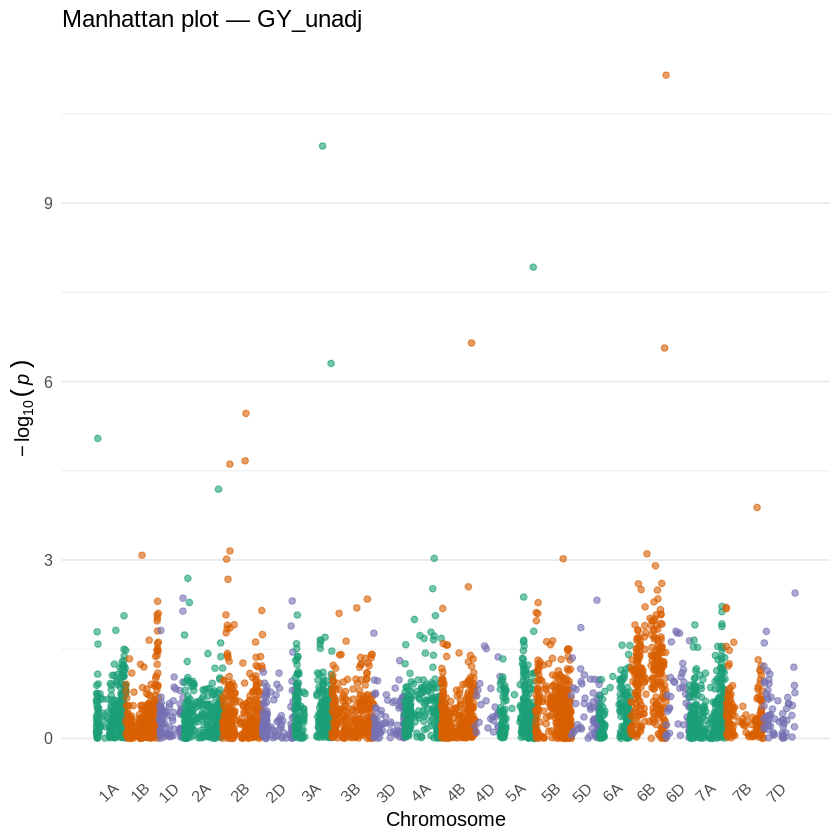

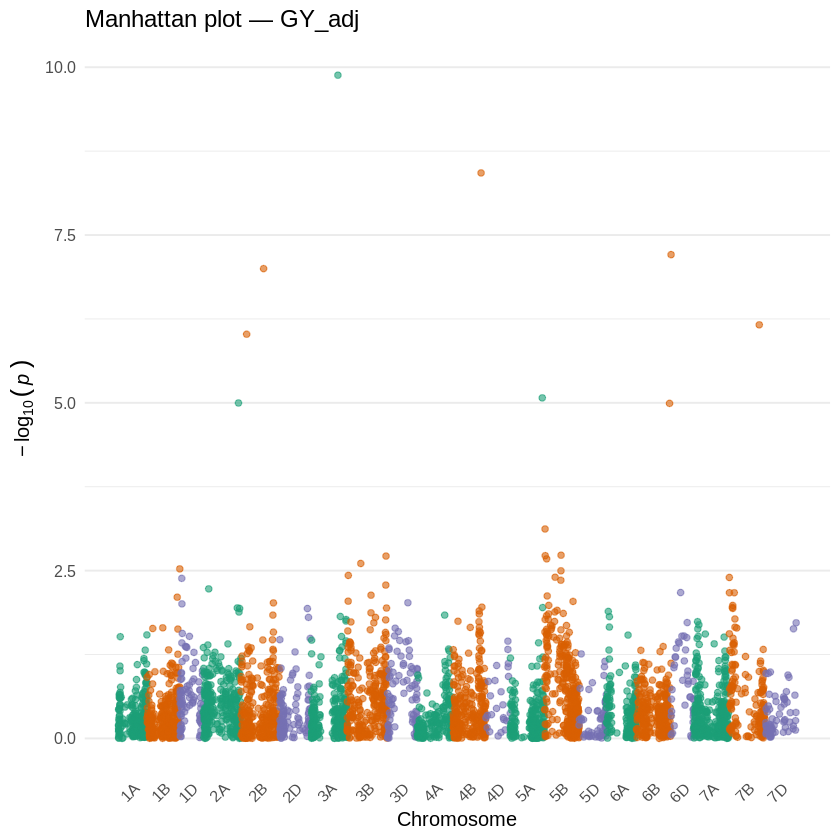

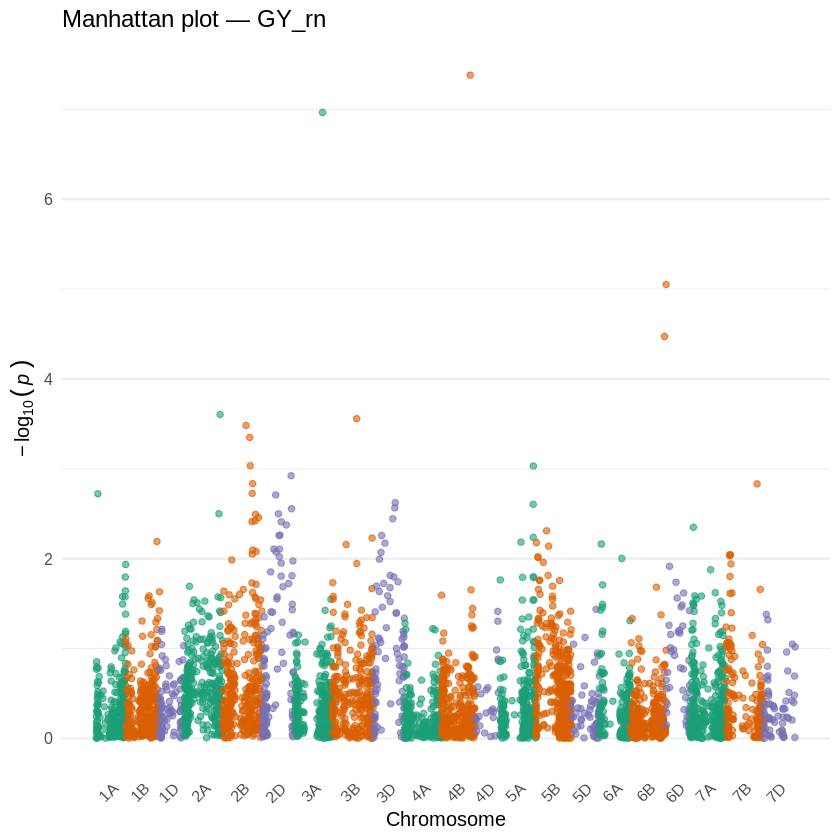

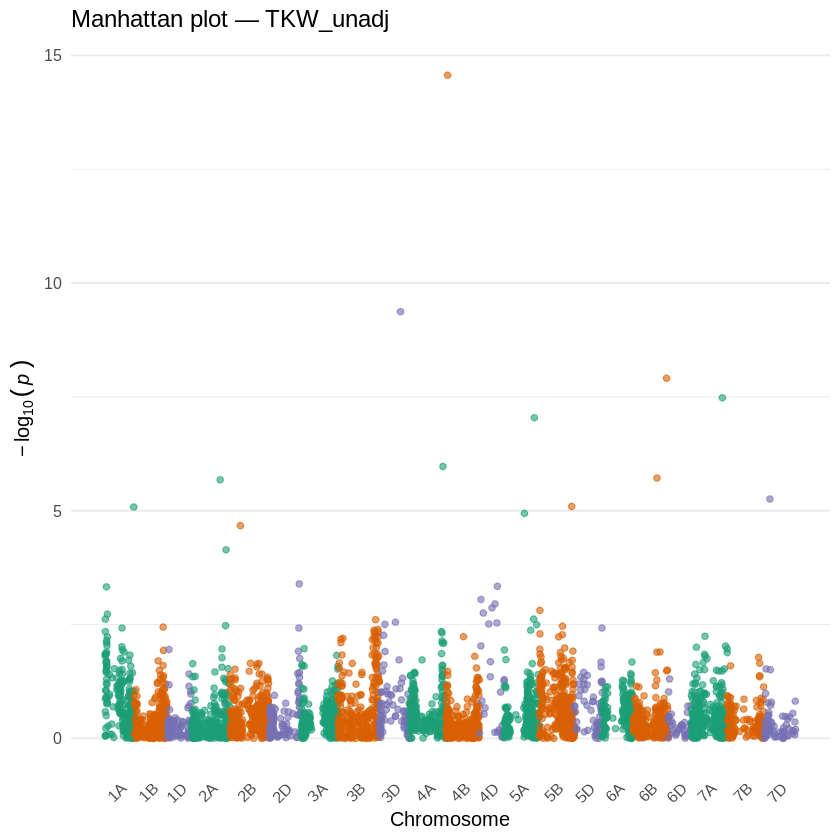

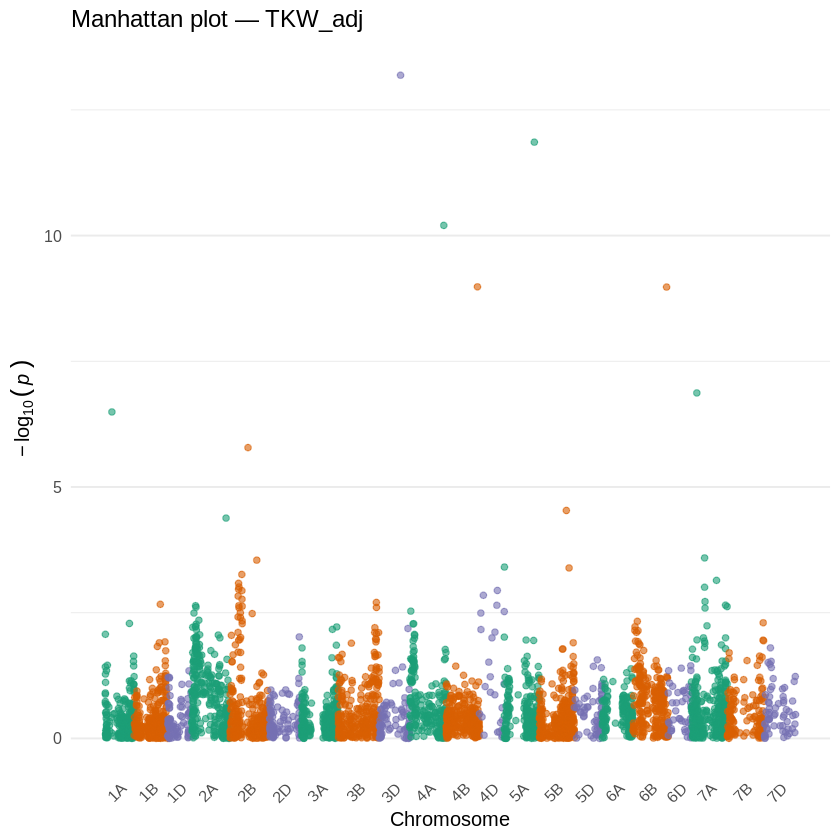

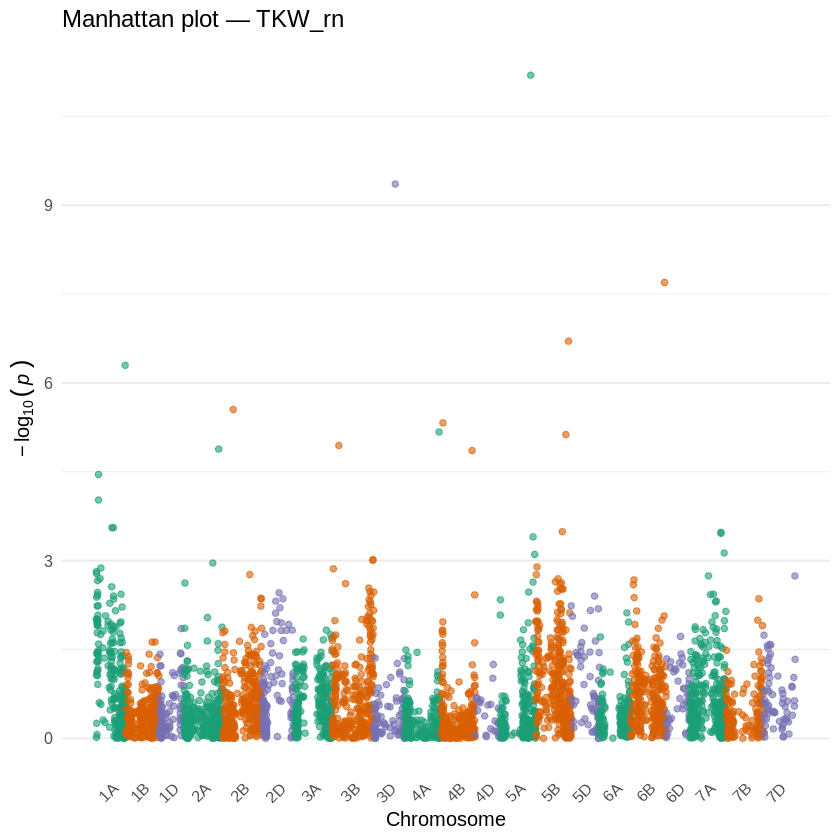

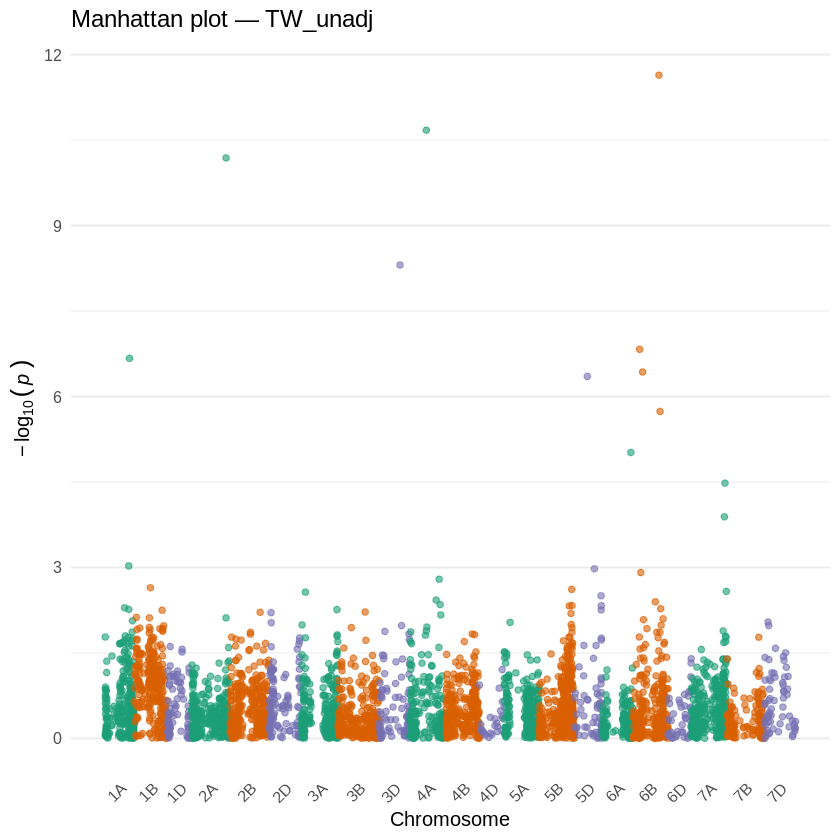

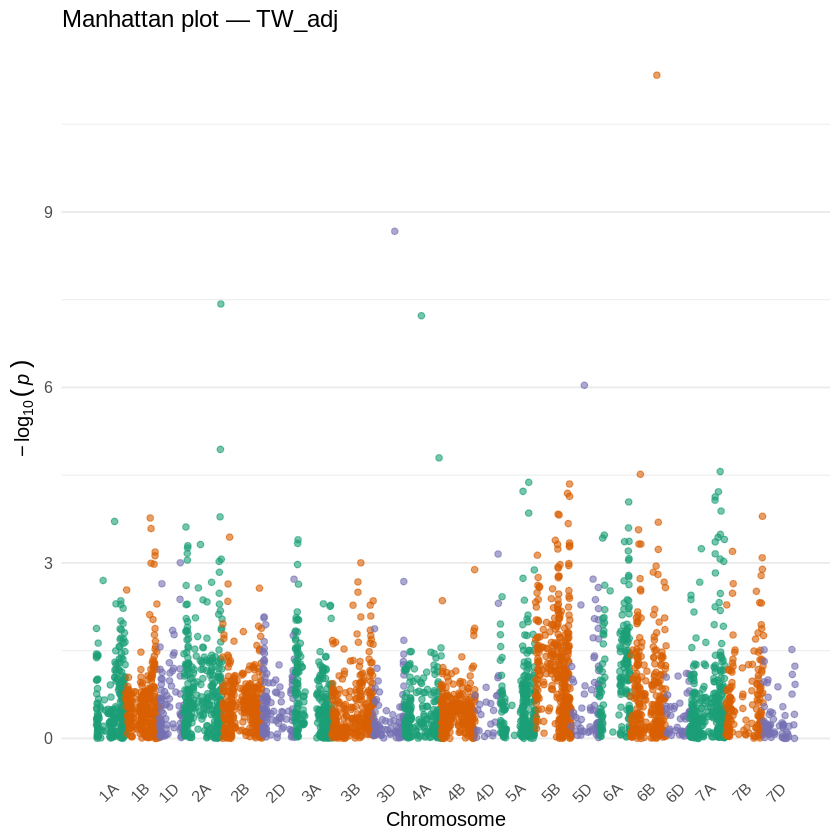

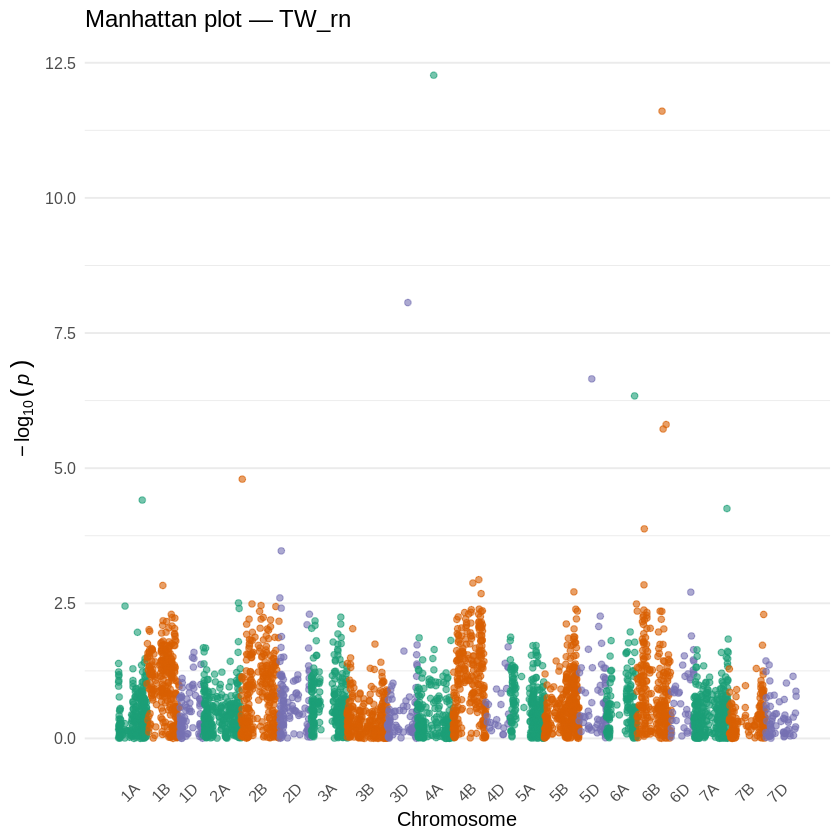

In [ ]:
### Run GWAS using GAPIT ###
# -- This takes around 10mins to run -- #
### Load marker data in Hapmap format ###
geno <- read_remote_geno(
  "Geno_GWAS.txt"
)

### Re-load modeled BLUPs as a text file (GAPIT requirement) ###
pheno <- read_remote_pheno(
  "Pheno.GAPIT.2.txt"
)

### Define color palette for Manhattan plots ###
pal <- brewer.pal(3, "Dark2")

### List of trait names ###
trait_list <- colnames(pheno)[-1]

### Loop over each trait ###
for (tr in trait_list) {

  # Run GWAS using Blink
  gwas_res <- suppressMessages(suppressWarnings({
    capture.output({
      tmp <- GAPIT(
        Y           = pheno %>% dplyr::select(Taxa, all_of(tr)),
        G           = geno,
        PCA.total   = 2,
        SNP.MAF     = 0.05,
        model       = "Blink",
        file.output = FALSE
      )
    }, file = NULL)
    tmp
  }))

  # Prepare dataframe for plotting
  df <- gwas_res$GWAS %>%
    mutate(
      CHR = str_extract(SNP, "(?<=chr)[0-9]+[ABD]"),
      CHR = factor(CHR, levels = unique(CHR)),
      Pos = Position,
      P   = P.value
    ) %>%
    dplyr::select(CHR, Pos, P)

  # Compute cumulative positions so chromosomes are plotted end-to-end
  chr_info <- df %>%
    group_by(CHR) %>%
    summarize(max_pos = max(Pos), .groups="drop") %>%
    mutate(
      chrom_start = lag(cumsum(max_pos), default = 0),
      chrom_mid   = chrom_start + max_pos/2
    )

  df <- df %>%
    left_join(chr_info, by = "CHR") %>%
    mutate(bp_cum = Pos + chrom_start)

  # Generate Manhattan plot
  p <- ggplot(df, aes(x = bp_cum, y = -log10(P), color = CHR)) +
    geom_point(alpha = 0.6, size = 1.5) +
    scale_color_manual(values = rep(pal, length.out = nrow(chr_info))) +
    scale_x_continuous(
      breaks = chr_info$chrom_mid,
      labels = chr_info$CHR
    ) +
    theme_minimal(base_size = 12) +
    theme(
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      axis.text.x        = element_text(angle = 45, hjust = 1),
      legend.position    = "none"
    ) +
    labs(
      x     = "Chromosome",
      y     = expression(-log[10](italic(p))),
      title = paste("Manhattan plot —", tr)
    )

  # 3e) Print the plot for this trait
  print(p)
}